# 📊 Statistica Bivariata — Chi Quadro & V di Cramér

> **Classe:** 4° anno Istituto Tecnico Informatico  
> **Prerequisiti:** variabili casuali, tabelle di frequenza, concetto di dipendenza statistica  
> **Obiettivi:** capire la statistica bivariata, costruire tabelle di contingenza, calcolare χ² e V di Cramér

---

## 🗺️ Mappa del tutorial

| Sezione | Argomento |
|---------|----------|
| 1 | Setup ambiente e import |
| 2 | Dataset: studenti e abitudini di studio |
| 3 | Analisi esplorativa (EDA) |
| 4 | Tabella di contingenza |
| 5 | Il test Chi Quadro (χ²) |
| 6 | La V di Cramér |
| 7 | Visualizzazioni |
| 8 | Esercizi per casa |

---

## 📌 Teoria rapida — cosa studia la statistica bivariata?

La **statistica univariata** studia *una* variabile alla volta (es. la distribuzione dei voti).  
La **statistica bivariata** studia la *relazione tra due variabili*: esiste un legame tra il metodo di studio e il voto finale?

Quando entrambe le variabili sono **categoriali** (nominali o ordinali), lo strumento principale è il **test del Chi Quadro (χ²)**.

> 💡 **Domanda guida di questo notebook:**  
> *C'è una relazione tra il metodo di studio preferito e il livello di rendimento scolastico degli studenti?*

---
## Sezione 1 — Setup ambiente

Questo notebook usa **uv** come gestore di pacchetti. Se usi VSCode con l'estensione Jupyter, esegui prima nel terminale:

```bash
# Crea il progetto e installa le dipendenze
uv init statistica_bivariata
cd statistica_bivariata
uv add pandas numpy scipy matplotlib seaborn

# Apri VSCode e seleziona l'interprete dalla cartella .venv
code .
```

> **In alternativa**, se stai già lavorando in una cartella con `pyproject.toml`, esegui solo:
> ```bash
> uv add pandas numpy scipy matplotlib seaborn
> ```

In [3]:
# ── Import delle librerie ──────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings('ignore')

# Stile grafici
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'monospace'
sns.set_theme(style='darkgrid', palette='muted')

print('✅ Librerie caricate correttamente!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   scipy   già importata')

✅ Librerie caricate correttamente!
   pandas  3.0.1
   numpy   2.4.2
   scipy   già importata


---
## Sezione 2 — Il Dataset

### 🎓 Scenario
Un istituto tecnico ha raccolto dati su **200 studenti** di quarta superiore. Per ciascuno sappiamo:

| Variabile | Tipo | Valori possibili |
|-----------|------|------------------|
| `metodo_studio` | Categoriale nominale | `Appunti`, `Video`, `Libro`, `Gruppo` |
| `rendimento` | Categoriale ordinale | `Basso`, `Medio`, `Alto` |
| `ore_studio` | Numerica continua | ore settimanali |
| `dispositivo` | Categoriale nominale | `PC`, `Tablet`, `Smartphone` |
| `sesso` | Categoriale nominale | `M`, `F` |

> 🔍 **Variabili di interesse principale:** `metodo_studio` e `rendimento`

In [4]:
# ── Generazione del dataset ────────────────────────────────────────────────
# Usiamo un seed fisso per garantire la riproducibilità
rng = np.random.default_rng(seed=42)

n = 200  # numero studenti

# Metodi di studio con probabilità diverse (non equiprobabili → più realistico)
metodi = ['Appunti', 'Video', 'Libro', 'Gruppo']
prob_metodi = [0.35, 0.30, 0.20, 0.15]
metodo_studio = rng.choice(metodi, size=n, p=prob_metodi)

# Rendimento: NON indipendente dal metodo → vogliamo vedere una relazione!
# Chi studia su libro o prende appunti tende ad avere rendimento più alto.
rendimento = []
for m in metodo_studio:
    if m == 'Libro':
        r = rng.choice(['Basso', 'Medio', 'Alto'], p=[0.10, 0.35, 0.55])
    elif m == 'Appunti':
        r = rng.choice(['Basso', 'Medio', 'Alto'], p=[0.20, 0.45, 0.35])
    elif m == 'Video':
        r = rng.choice(['Basso', 'Medio', 'Alto'], p=[0.30, 0.45, 0.25])
    else:  # Gruppo
        r = rng.choice(['Basso', 'Medio', 'Alto'], p=[0.40, 0.40, 0.20])
    rendimento.append(r)

# Altre variabili
ore_studio = np.round(
    rng.normal(loc=8, scale=3, size=n).clip(1, 20), 1
)
dispositivo = rng.choice(['PC', 'Tablet', 'Smartphone'], size=n, p=[0.50, 0.25, 0.25])
sesso = rng.choice(['M', 'F'], size=n, p=[0.52, 0.48])

# Costruzione del DataFrame
df = pd.DataFrame({
    'metodo_studio': metodo_studio,
    'rendimento': rendimento,
    'ore_studio': ore_studio,
    'dispositivo': dispositivo,
    'sesso': sesso
})

# Rendiamo ordinale la colonna rendimento
ordine_rend = pd.CategoricalDtype(categories=['Basso', 'Medio', 'Alto'], ordered=True)
df['rendimento'] = df['rendimento'].astype(ordine_rend)

print(f'Dataset creato: {df.shape[0]} righe × {df.shape[1]} colonne')
df.head(10)
df.to_csv('studenti_studio.csv', index=False)
print('✅ Dataset salvato come "studenti_studio.csv"')

Dataset creato: 200 righe × 5 colonne
✅ Dataset salvato come "studenti_studio.csv"


In [5]:
# ── Info generali ──────────────────────────────────────────────────────────
print('=== INFORMAZIONI SUL DATASET ===')
df.info()
print('\n=== STATISTICHE DESCRITTIVE ===')
df.describe(include='all')

=== INFORMAZIONI SUL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   metodo_studio  200 non-null    str     
 1   rendimento     200 non-null    category
 2   ore_studio     200 non-null    float64 
 3   dispositivo    200 non-null    str     
 4   sesso          200 non-null    str     
dtypes: category(1), float64(1), str(3)
memory usage: 6.7 KB

=== STATISTICHE DESCRITTIVE ===


,metodo_studio,rendimento,ore_studio,dispositivo,sesso
count,200,200,200.000000,200,200
unique,4,3,NaN,3,2
top,Appunti,Medio,NaN,PC,M
freq,71,84,NaN,107,103
mean,NaN,NaN,7.854500,NaN,NaN
std,NaN,NaN,2.964426,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN
25%,NaN,NaN,5.875000,NaN,NaN
50%,NaN,NaN,7.850000,NaN,NaN
75%,NaN,NaN,9.625000,NaN,NaN


---
## Sezione 3 — Analisi Esplorativa (EDA)

Prima di qualsiasi test statistico, **guardiamo i dati** con le frequenze e qualche grafico.

In [6]:
# ── Frequenze delle singole variabili ─────────────────────────────────────
print('=== DISTRIBUZIONE: metodo_studio ===')
freq_metodo = df['metodo_studio'].value_counts(normalize=False)
freq_metodo_pct = df['metodo_studio'].value_counts(normalize=True).mul(100).round(1)
print(pd.DataFrame({'Conteggio': freq_metodo, 'Percentuale %': freq_metodo_pct}))

print('\n=== DISTRIBUZIONE: rendimento ===')
freq_rend = df['rendimento'].value_counts(sort=False)
freq_rend_pct = df['rendimento'].value_counts(sort=False, normalize=True).mul(100).round(1)
print(pd.DataFrame({'Conteggio': freq_rend, 'Percentuale %': freq_rend_pct}))

=== DISTRIBUZIONE: metodo_studio ===
               Conteggio  Percentuale %
metodo_studio                          
Appunti               71           35.5
Video                 58           29.0
Libro                 46           23.0
Gruppo                25           12.5

=== DISTRIBUZIONE: rendimento ===
            Conteggio  Percentuale %
rendimento                          
Basso              47           23.5
Medio              84           42.0
Alto               69           34.5


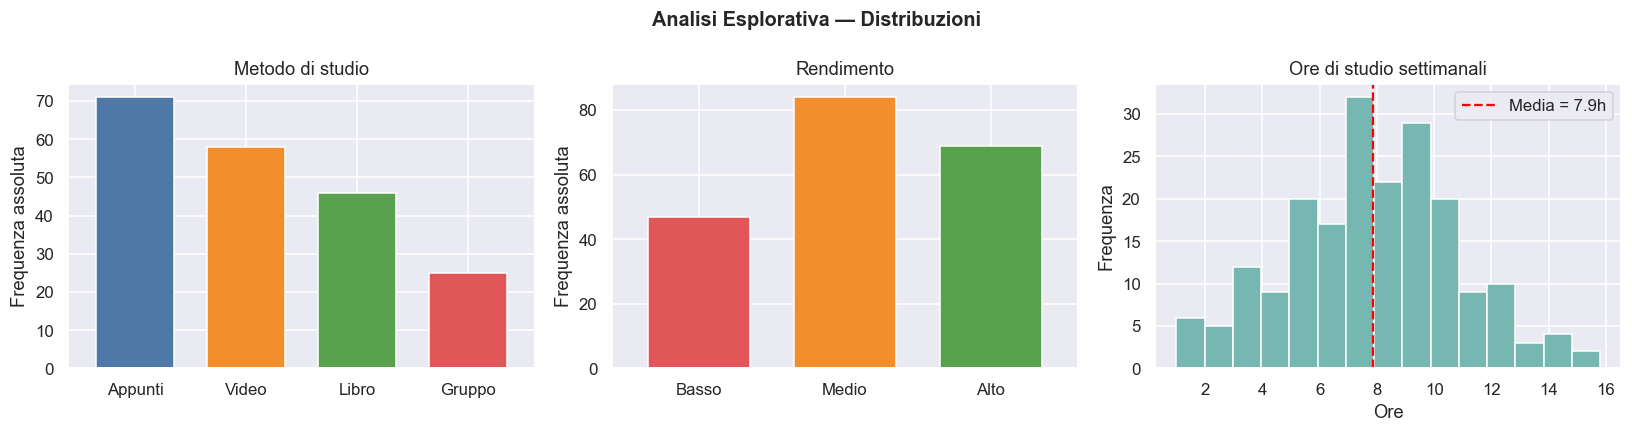

In [7]:
# ── Grafici EDA ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Analisi Esplorativa — Distribuzioni', fontsize=13, fontweight='bold')

# 1. Metodo di studio
colori_metodi = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
df['metodo_studio'].value_counts().plot(
    kind='bar', ax=axes[0], color=colori_metodi, edgecolor='white', width=0.7
)
axes[0].set_title('Metodo di studio')
axes[0].set_xlabel('')
axes[0].set_ylabel('Frequenza assoluta')
axes[0].tick_params(axis='x', rotation=0)

# 2. Rendimento
colori_rend = ['#e15759', '#f28e2b', '#59a14f']
df['rendimento'].value_counts(sort=False).plot(
    kind='bar', ax=axes[1], color=colori_rend, edgecolor='white', width=0.7
)
axes[1].set_title('Rendimento')
axes[1].set_xlabel('')
axes[1].set_ylabel('Frequenza assoluta')
axes[1].tick_params(axis='x', rotation=0)

# 3. Ore di studio
axes[2].hist(df['ore_studio'], bins=15, color='#76b7b2', edgecolor='white')
axes[2].axvline(df['ore_studio'].mean(), color='red', linestyle='--', label=f'Media = {df["ore_studio"].mean():.1f}h')
axes[2].set_title('Ore di studio settimanali')
axes[2].set_xlabel('Ore')
axes[2].set_ylabel('Frequenza')
axes[2].legend()

plt.tight_layout()
plt.show()

---
## Sezione 4 — Tabella di Contingenza

### 📖 Teoria

Una **tabella di contingenza** (o tabella a doppia entrata) mostra le **frequenze osservate** di ogni combinazione tra le categorie di due variabili.

$$
\begin{array}{c|ccc|c}
 & \text{Basso} & \text{Medio} & \text{Alto} & \text{Totale} \\
\hline
\text{Appunti} & O_{11} & O_{12} & O_{13} & R_1 \\
\text{Video}   & O_{21} & O_{22} & O_{23} & R_2 \\
\text{Libro}   & O_{31} & O_{32} & O_{33} & R_3 \\
\text{Gruppo}  & O_{41} & O_{42} & O_{43} & R_4 \\
\hline
\text{Totale}  & C_1    & C_2    & C_3    & N  \\
\end{array}
$$

Dove $O_{ij}$ = frequenza **osservata** per la cella $(i, j)$.

In [8]:
# ── Tabella di contingenza (frequenze assolute) ────────────────────────────
tab_obs = pd.crosstab(
    df['metodo_studio'],
    df['rendimento'],
    margins=True,       # aggiunge i totali di riga e colonna
    margins_name='TOT'
)
print('=== FREQUENZE OSSERVATE (O_ij) ===')
print(tab_obs)
print(f'\nN totale = {tab_obs.loc["TOT", "TOT"]}')

=== FREQUENZE OSSERVATE (O_ij) ===
rendimento     Basso  Medio  Alto  TOT
metodo_studio                         
Appunti           15     33    23   71
Gruppo            11     10     4   25
Libro              4     18    24   46
Video             17     23    18   58
TOT               47     84    69  200

N totale = 200


In [9]:
# ── Tabella con percentuali di riga ───────────────────────────────────────
# Ci aiuta a leggere: "tra chi usa il Libro, quanti hanno rendimento Alto?"
tab_pct_riga = pd.crosstab(
    df['metodo_studio'],
    df['rendimento'],
    normalize='index'  # normalizza per riga → percentuali di riga
).mul(100).round(1)

print('=== PERCENTUALI PER RIGA (% dentro ogni metodo di studio) ===')
print(tab_pct_riga)
print('\n💬 Interpretazione: ogni riga somma a 100%.')
print('   Se le distribuzioni fossero IDENTICHE tra le righe → nessuna relazione.')
print('   Se le distribuzioni DIFFERISCONO → potrebbe esserci relazione.')

=== PERCENTUALI PER RIGA (% dentro ogni metodo di studio) ===
rendimento     Basso  Medio  Alto
metodo_studio                    
Appunti         21.1   46.5  32.4
Gruppo          44.0   40.0  16.0
Libro            8.7   39.1  52.2
Video           29.3   39.7  31.0

💬 Interpretazione: ogni riga somma a 100%.
   Se le distribuzioni fossero IDENTICHE tra le righe → nessuna relazione.
   Se le distribuzioni DIFFERISCONO → potrebbe esserci relazione.


---
## Sezione 5 — Il Test del Chi Quadro (χ²)

### 📖 Teoria

Il test χ² risponde alla domanda:
> *Le differenze che vediamo nella tabella di contingenza sono dovute al caso, oppure c'è una vera relazione tra le variabili?*

**Ipotesi:**
- **H₀ (ipotesi nulla):** le due variabili sono **indipendenti** (nessuna relazione)
- **H₁ (ipotesi alternativa):** le due variabili sono **dipendenti** (esiste relazione)

**Frequenze attese** sotto H₀ — se le variabili fossero indipendenti:

$$E_{ij} = \frac{R_i \cdot C_j}{N}$$

dove $R_i$ = totale riga $i$, $C_j$ = totale colonna $j$, $N$ = totale complessivo.

**Statistica χ²:**

$$\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$$

**Gradi di libertà:**
$$df = (r - 1)(c - 1)$$

dove $r$ = numero righe, $c$ = numero colonne.

**Regola di decisione:**  
Se il **p-value** < soglia α (di solito 0.05) → **rifiutiamo H₀** → le variabili non sono indipendenti.

> ⚠️ **Condizione di applicabilità:** ogni frequenza attesa $E_{ij}$ deve essere ≥ 5.

In [10]:
# ── Step 1: Tabella senza margini (solo i valori O_ij) ────────────────────
tab_raw = pd.crosstab(df['metodo_studio'], df['rendimento'])
print('Tabella osservazioni (senza margini):')
print(tab_raw)

Tabella osservazioni (senza margini):
rendimento     Basso  Medio  Alto
metodo_studio                    
Appunti           15     33    23
Gruppo            11     10     4
Libro              4     18    24
Video             17     23    18


In [11]:
# ── Step 2: Calcolo delle frequenze ATTESE a mano ─────────────────────────
# Formula: E_ij = (totale_riga_i * totale_col_j) / N

N = tab_raw.values.sum()               # totale generale
totali_riga = tab_raw.sum(axis=1)      # somma per ogni riga
print('Totali per riga:', totali_riga)
totali_col  = tab_raw.sum(axis=0)      # somma per ogni colonna
print('Totali per colonna:', totali_col)

# Prodotto esterno → matrice E_ij
E = np.outer(totali_riga.values, totali_col.values) / N
print('Matrice delle frequenze attese (E_ij):', E)
tab_attese = pd.DataFrame(E, index=tab_raw.index, columns=tab_raw.columns)

print(f'N = {N}')
print('\n=== FREQUENZE ATTESE (E_ij) ===')
print(tab_attese.round(2))

# Verifica condizione di applicabilità
min_attesa = tab_attese.values.min()
print(f'\n✅ Frequenza attesa minima = {min_attesa:.2f}', end=' ')
print('→ Condizione E_ij ≥ 5 rispettata!' if min_attesa >= 5 else '⚠️ Attenzione: qualche E_ij < 5!')

Totali per riga: metodo_studio
Appunti    71
Gruppo     25
Libro      46
Video      58
dtype: int64
Totali per colonna: rendimento
Basso    47
Medio    84
Alto     69
dtype: int64
Matrice delle frequenze attese (E_ij): [[16.685 29.82  24.495]
 [ 5.875 10.5    8.625]
 [10.81  19.32  15.87 ]
 [13.63  24.36  20.01 ]]
N = 200

=== FREQUENZE ATTESE (E_ij) ===
rendimento     Basso  Medio   Alto
metodo_studio                     
Appunti        16.68  29.82  24.50
Gruppo          5.88  10.50   8.62
Libro          10.81  19.32  15.87
Video          13.63  24.36  20.01

✅ Frequenza attesa minima = 5.88 → Condizione E_ij ≥ 5 rispettata!


In [ ]:
# ── Step 3: Calcolo χ² a mano ─────────────────────────────────────────────
O = tab_raw.values.astype(float)
print('0:', O)

E_mat = tab_attese.values
print('E_mat:', E_mat)

# Contributi di ogni cella
contributi = (O - E_mat)**2 / E_mat
chi2_manuale = contributi.sum()

r, c = O.shape
df_gradi = (r - 1) * (c - 1)

print('=== CONTRIBUTI χ² PER CELLA ===')
tab_contrib = pd.DataFrame(contributi, index=tab_raw.index, columns=tab_raw.columns)
print(tab_contrib.round(4))

print(f'\n┌─────────────────────────────────────────┐')
print(f'│  χ² calcolato      = {chi2_manuale:.4f}           │')
print(f'│  Gradi di libertà  = {df_gradi}  (= ({r}-1)×({c}-1)) │')
print(f'└─────────────────────────────────────────┘')
print('\n💬 Più χ² è grande, più le O_ij si discostano dalle E_ij → più forte la relazione.')

0: [[15. 33. 23.]
 [11. 10.  4.]
 [ 4. 18. 24.]
 [17. 23. 18.]]
E_mat: [[16.685 29.82  24.495]
 [ 5.875 10.5    8.625]
 [10.81  19.32  15.87 ]
 [13.63  24.36  20.01 ]]
=== CONTRIBUTI χ² PER CELLA ===
rendimento      Basso   Medio    Alto
metodo_studio                        
Appunti        0.1702  0.3391  0.0912
Gruppo         4.4707  0.0238  2.4801
Libro          4.2901  0.0902  4.1649
Video          0.8332  0.0759  0.2019

┌─────────────────────────────────────────┐
│  χ² calcolato      = 17.2314           │
│  Gradi di libertà  = 6  (= (4-1)×(3-1)) │
└─────────────────────────────────────────┘

💬 Più χ² è grande, più le O_ij si discostano dalle E_ij → più forte la relazione.


In [13]:
# ── Step 4: Test con scipy (verifica) ─────────────────────────────────────
chi2_scipy, p_value, df_scipy, freq_attese_scipy = chi2_contingency(tab_raw)

alpha = 0.05  # livello di significatività

print('=== RISULTATI TEST χ² (scipy) ===')
print(f'  χ²          = {chi2_scipy:.4f}')
print(f'  p-value     = {p_value:.6f}')
print(f'  df          = {df_scipy}')
print(f'  α           = {alpha}')
print()

if p_value < alpha:
    print(f'✅ p-value ({p_value:.6f}) < α ({alpha})')
    print('   → RIFIUTIAMO H₀: le variabili NON sono indipendenti.')
    print('   → Esiste una relazione statisticamente significativa tra')
    print('     metodo di studio e rendimento scolastico.')
else:
    print(f'❌ p-value ({p_value:.6f}) ≥ α ({alpha})')
    print('   → NON rifiutiamo H₀: non abbiamo prove sufficienti di dipendenza.')

print(f'\n🔁 Verifica coerenza calcolo manuale: χ² manuale = {chi2_manuale:.4f}, scipy = {chi2_scipy:.4f}')

=== RISULTATI TEST χ² (scipy) ===
  χ²          = 17.2314
  p-value     = 0.008469
  df          = 6
  α           = 0.05

✅ p-value (0.008469) < α (0.05)
   → RIFIUTIAMO H₀: le variabili NON sono indipendenti.
   → Esiste una relazione statisticamente significativa tra
     metodo di studio e rendimento scolastico.

🔁 Verifica coerenza calcolo manuale: χ² manuale = 17.2314, scipy = 17.2314


---
## Sezione 6 — La V di Cramér

### 📖 Teoria

Il χ² ci dice **se** esiste una relazione, ma non **quanto è forte**.  
Due dataset diversi con relazioni di intensità molto diverse possono dare lo stesso χ² se hanno numerosità N diverse.

La **V di Cramér** normalizza χ² e produce un valore tra 0 e 1:

$$V = \sqrt{\frac{\chi^2}{N \cdot \min(r-1,\, c-1)}}$$

| V di Cramér | Interpretazione |
|-------------|----------------|
| 0.00 – 0.10 | Relazione trascurabile |
| 0.10 – 0.20 | Relazione debole |
| 0.20 – 0.40 | Relazione moderata |
| 0.40 – 0.60 | Relazione forte |
| > 0.60      | Relazione molto forte |

> ⚠️ I range sopra sono indicativi. In letteratura esistono soglie leggermente diverse.

In [14]:
# ── Calcolo V di Cramér ───────────────────────────────────────────────────
def cramer_v(chi2, n, r, c):
    """
    Calcola la V di Cramér.
    
    Parametri:
    ----------
    chi2 : float — valore χ² dal test
    n    : int   — numerosità totale del campione
    r    : int   — numero di categorie della variabile riga
    c    : int   — numero di categorie della variabile colonna
    
    Ritorna:
    --------
    float — valore V di Cramér in [0, 1]
    """
    k = min(r - 1, c - 1)   # denominatore
    return np.sqrt(chi2 / (n * k))


# Applicazione al nostro dataset
r_n, c_n = tab_raw.shape
v = cramer_v(chi2_scipy, N, r_n, c_n)

# Interpretazione
def interpreta_v(v):
    if v < 0.10: return 'trascurabile'
    elif v < 0.20: return 'debole'
    elif v < 0.40: return 'moderata'
    elif v < 0.60: return 'forte'
    else: return 'molto forte'

print('=== V di CRAMÉR ===')
print(f'  χ²                     = {chi2_scipy:.4f}')
print(f'  N                      = {N}')
print(f'  min(r-1, c-1)          = {min(r_n-1, c_n-1)}')
print(f'  ─────────────────────────────────')
print(f'  V = √({chi2_scipy:.4f} / ({N} × {min(r_n-1,c_n-1)}))')
print(f'  V = {v:.4f}')
print()
print(f'📊 Interpretazione: relazione {interpreta_v(v).upper()}')
print(f'   V = {v:.4f} indica che metodo di studio e rendimento')
print(f'   hanno una relazione {interpreta_v(v)} ma statisticamente significativa.')

=== V di CRAMÉR ===
  χ²                     = 17.2314
  N                      = 200
  min(r-1, c-1)          = 2
  ─────────────────────────────────
  V = √(17.2314 / (200 × 2))
  V = 0.2076

📊 Interpretazione: relazione MODERATA
   V = 0.2076 indica che metodo di studio e rendimento
   hanno una relazione moderata ma statisticamente significativa.


In [15]:
# ── Riepilogo finale ──────────────────────────────────────────────────────
print('=' * 50)
print('         RIEPILOGO DEI RISULTATI')
print('=' * 50)
print(f'  Variabile X : metodo_studio ({r_n} categorie)')
print(f'  Variabile Y : rendimento    ({c_n} categorie)')
print(f'  N campione  : {N} studenti')
print()
print(f'  χ²          = {chi2_scipy:.4f}')
print(f'  df          = {df_scipy}')
print(f'  p-value     = {p_value:.6f}')
print(f'  V di Cramér = {v:.4f}  ({interpreta_v(v)})')
print()
print(f'  Conclusione: relazione {"SIGNIFICATIVA" if p_value < 0.05 else "NON significativa"}')
print('=' * 50)

         RIEPILOGO DEI RISULTATI
  Variabile X : metodo_studio (4 categorie)
  Variabile Y : rendimento    (3 categorie)
  N campione  : 200 studenti

  χ²          = 17.2314
  df          = 6
  p-value     = 0.008469
  V di Cramér = 0.2076  (moderata)

  Conclusione: relazione SIGNIFICATIVA


---
## Sezione 7 — Visualizzazioni

I grafici aiutano a *comunicare* i risultati statistici.

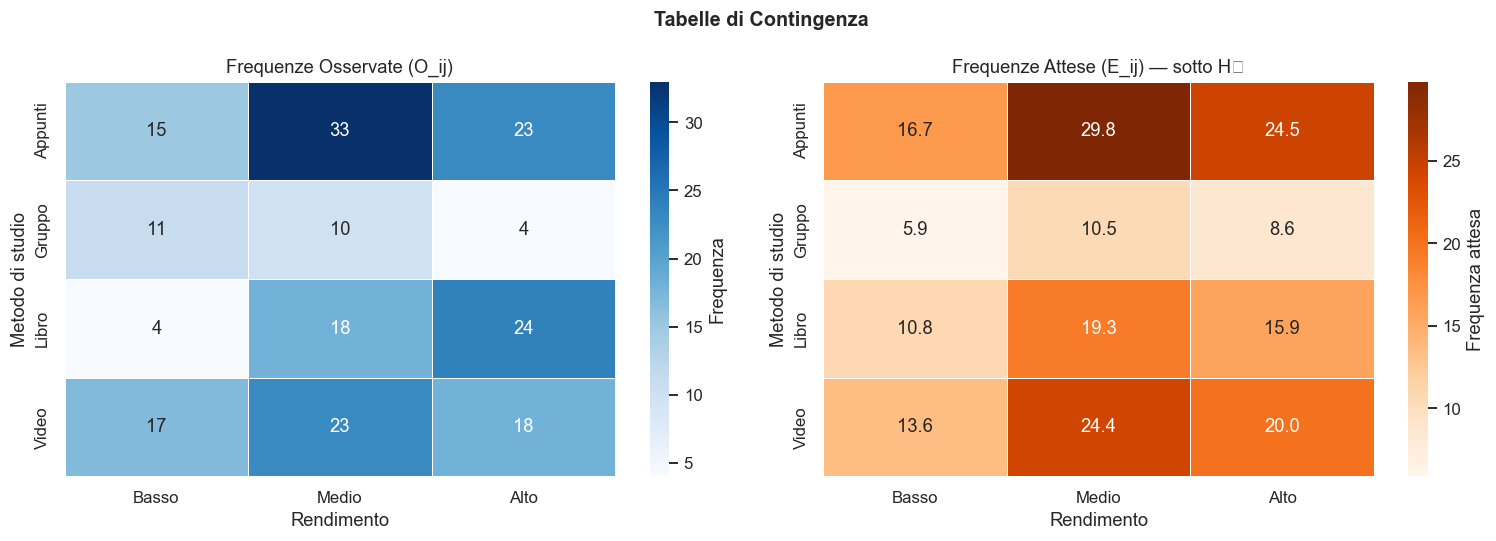

💬 Se O_ij ≈ E_ij per tutte le celle → variabili indipendenti.
   Grandi scostamenti → relazione (χ² alto).


In [16]:
# ── Grafico 1: Heatmap tabella di contingenza ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tabelle di Contingenza', fontsize=13, fontweight='bold')

# Frequenze assolute
sns.heatmap(
    tab_raw,
    annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, ax=axes[0],
    cbar_kws={'label': 'Frequenza'}
)
axes[0].set_title('Frequenze Osservate (O_ij)')
axes[0].set_xlabel('Rendimento')
axes[0].set_ylabel('Metodo di studio')

# Frequenze attese
sns.heatmap(
    tab_attese,
    annot=True, fmt='.1f', cmap='Oranges',
    linewidths=0.5, ax=axes[1],
    cbar_kws={'label': 'Frequenza attesa'}
)
axes[1].set_title('Frequenze Attese (E_ij) — sotto H₀')
axes[1].set_xlabel('Rendimento')
axes[1].set_ylabel('Metodo di studio')

plt.tight_layout()
plt.show()
print('💬 Se O_ij ≈ E_ij per tutte le celle → variabili indipendenti.')
print('   Grandi scostamenti → relazione (χ² alto).')

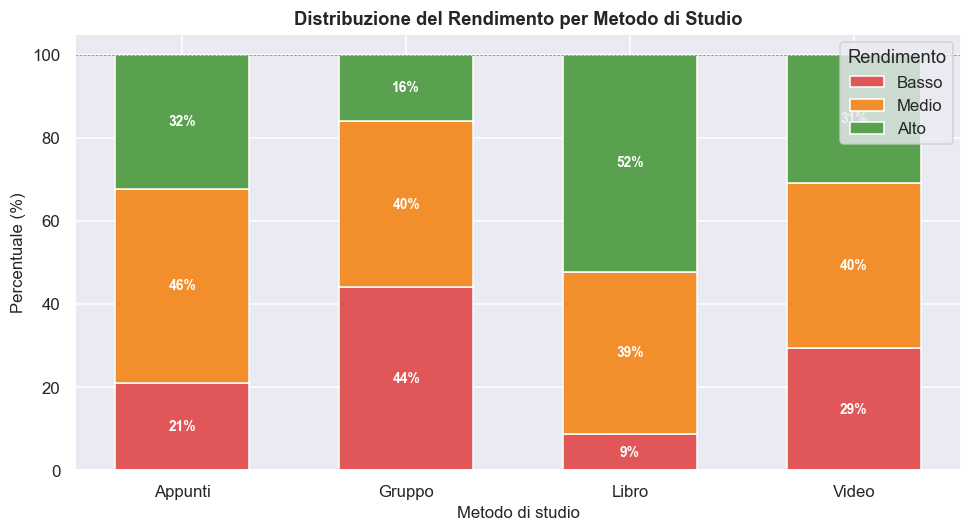

💬 Se le barre fossero tutte identiche → indipendenza.
   Le differenze visibili motivano il nostro test χ².


In [17]:
# ── Grafico 2: Bar chart impilato (% di riga) ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colori = {'Basso': '#e15759', 'Medio': '#f28e2b', 'Alto': '#59a14f'}
bottom = np.zeros(len(tab_pct_riga))

for col in ['Basso', 'Medio', 'Alto']:
    valori = tab_pct_riga[col].values
    ax.bar(tab_pct_riga.index, valori, bottom=bottom,
           label=col, color=colori[col], edgecolor='white', width=0.6)
    # Etichette dentro le barre
    for i, (val, bot) in enumerate(zip(valori, bottom)):
        if val > 6:
            ax.text(i, bot + val/2, f'{val:.0f}%',
                    ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += valori

ax.set_xlabel('Metodo di studio', fontsize=11)
ax.set_ylabel('Percentuale (%)', fontsize=11)
ax.set_title('Distribuzione del Rendimento per Metodo di Studio', fontsize=12, fontweight='bold')
ax.legend(title='Rendimento', loc='upper right')
ax.set_ylim(0, 105)
ax.axhline(100, color='grey', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()
print('💬 Se le barre fossero tutte identiche → indipendenza.')
print('   Le differenze visibili motivano il nostro test χ².')

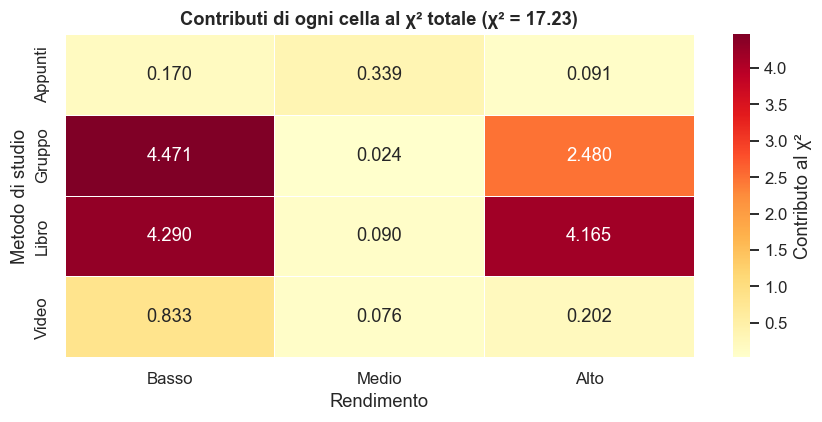

💬 Le celle più rosse sono quelle che contribuiscono di più al χ².
   Indicano le combinazioni con il maggior scostamento tra O e E.


In [18]:
# ── Grafico 3: Contributi χ² per cella ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

sns.heatmap(
    tab_contrib,
    annot=True, fmt='.3f', cmap='YlOrRd',
    linewidths=0.5, ax=ax,
    cbar_kws={'label': 'Contributo al χ²'}
)
ax.set_title(f'Contributi di ogni cella al χ² totale (χ² = {chi2_scipy:.2f})', fontweight='bold')
ax.set_xlabel('Rendimento')
ax.set_ylabel('Metodo di studio')

plt.tight_layout()
plt.show()
print('💬 Le celle più rosse sono quelle che contribuiscono di più al χ².')
print('   Indicano le combinazioni con il maggior scostamento tra O e E.')

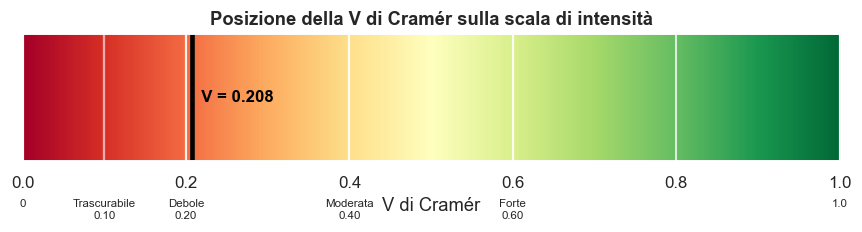

In [19]:
# ── Grafico 4: Interpretazione visiva della V di Cramér ──────────────────
fig, ax = plt.subplots(figsize=(8, 2.5))

# Barra colore gradiente
gradient = np.linspace(0, 1, 256).reshape(1, -1)
ax.imshow(gradient, aspect='auto', cmap='RdYlGn', extent=[0, 1, 0, 1])

# Etichette soglie
soglie = [0, 0.10, 0.20, 0.40, 0.60, 1.0]
etichette = ['0', 'Trascurabile\n0.10', 'Debole\n0.20', 'Moderata\n0.40', 'Forte\n0.60', '1.0']
for s, e in zip(soglie, etichette):
    ax.axvline(s, color='white', linewidth=1.5, alpha=0.6)
    ax.text(s, -0.3, e, ha='center', va='top', fontsize=7.5, transform=ax.get_xaxis_transform())

# Marcatore V attuale
ax.axvline(v, color='black', linewidth=3)
ax.text(v, 0.5, f'  V = {v:.3f}', va='center', fontsize=11, fontweight='bold', color='black')

ax.set_xlim(0, 1)
ax.set_yticks([])
ax.set_title('Posizione della V di Cramér sulla scala di intensità', fontweight='bold')
ax.set_xlabel('V di Cramér')

plt.tight_layout()
plt.show()

---
## Sezione 8 — Bonus: Dataset reale da Kaggle

Se vuoi provare con un dataset reale invece del sintetico, ti consiglio:

### 📦 Dataset consigliato: **Student Performance in Exams**
- **URL:** https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
- **File:** `StudentsPerformance.csv`
- **Perché è adatto:** contiene variabili categoriali come `parental level of education`, `lunch`, `test preparation course` e punteggi numerici che puoi convertire in fasce (Basso/Medio/Alto)

```bash
# Scarica via Kaggle CLI (richiede account Kaggle e API key)
uv add kaggle
kaggle datasets download -d spscientist/students-performance-in-exams
unzip students-performance-in-exams.zip
```

Poi adatta il codice così:

In [20]:
# ── Codice adattato per il dataset Kaggle ─────────────────────────────────
# Decommentare e eseguire dopo aver scaricato il file CSV

# df_kaggle = pd.read_csv('StudentsPerformance.csv')
# print(df_kaggle.head())
# print(df_kaggle.columns.tolist())

# # Converti il punteggio in fasce categoriali
# df_kaggle['fascia_punteggio'] = pd.cut(
#     df_kaggle['math score'],
#     bins=[0, 49, 69, 100],
#     labels=['Basso', 'Medio', 'Alto']
# )

# # Test χ² e V di Cramér: preparazione al corso vs fascia punteggio
# tab_k = pd.crosstab(df_kaggle['test preparation course'], df_kaggle['fascia_punteggio'])
# chi2_k, p_k, df_k, _ = chi2_contingency(tab_k)
# v_k = cramer_v(chi2_k, len(df_kaggle), *tab_k.shape)
# print(f'χ² = {chi2_k:.4f}, p-value = {p_k:.6f}, V = {v_k:.4f}')

print('💡 Decommenta il codice sopra dopo aver scaricato StudentsPerformance.csv')

💡 Decommenta il codice sopra dopo aver scaricato StudentsPerformance.csv


---
## Sezione 9 — Esercizi per Casa 🏠

Prova a rispondere a queste domande usando il dataset di questo notebook:

### ✏️ Esercizio 1 — Analisi diversa
Esegui il test χ² e calcola la V di Cramér per la coppia:  
**`dispositivo`** (PC / Tablet / Smartphone) e **`rendimento`** (Basso / Medio / Alto).  
Esiste una relazione? Quanto è forte?

### ✏️ Esercizio 2 — Soglia diversa
Ripeti il test χ² tra `metodo_studio` e `rendimento` con **α = 0.01**.  
Cambia la conclusione?

### ✏️ Esercizio 3 — Ragionamento critico
Se χ² = 50 con N = 1000, e un secondo studio ha χ² = 50 con N = 100:  
- Il p-value sarà diverso tra i due?
- La V di Cramér sarà diversa?
- Qual è il vantaggio della V rispetto al χ²?

### ✏️ Esercizio 4 — Dati sintetici alternativi
Modifica la cella di generazione del dataset per creare un caso di **indipendenza perfetta**  
(stesse probabilità di rendimento per tutti i metodi).  
Cosa succede a χ² e V di Cramér?

---

## 📚 Risorse aggiuntive

| Risorsa | Link |
|---------|------|
| Documentazione scipy.stats | https://docs.scipy.org/doc/scipy/reference/stats.html |
| Pandas crosstab | https://pandas.pydata.org/docs/reference/api/pandas.crosstab.html |
| Dataset Kaggle consigliato | https://www.kaggle.com/datasets/spscientist/students-performance-in-exams |
| uv (gestore pacchetti) | https://docs.astral.sh/uv/ |

---
*Tutorial realizzato per classe 4° ITI — Statistica Bivariata*